<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/ml/12-unsupervised-learning/DBSCAN-clustering/Project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
import pandas as pd
import seaborn as sns

## Creating moons dataset

In [2]:
from sklearn.datasets import make_moons
data = make_moons(n_samples = 100, random_state = 42)

In [3]:
type(data)

tuple

In [4]:
len(data)

2

In [5]:
data

(array([[ 1.51839257e+00, -3.55142763e-01],
        [ 1.84408430e-02,  3.08841371e-01],
        [ 7.15472413e-01, -4.58667853e-01],
        [-9.67294863e-01,  2.53654584e-01],
        [-9.49055747e-01,  3.15108218e-01],
        [-8.01413622e-01,  5.98110530e-01],
        [ 1.59599895e-01,  9.87181783e-01],
        [ 1.34536505e+00, -4.38468422e-01],
        [ 8.01413622e-01,  5.98110530e-01],
        [ 1.00000000e+00,  0.00000000e+00],
        [ 4.04783343e-01,  9.14412623e-01],
        [-3.45365054e-01,  9.38468422e-01],
        [ 9.03976974e-01, -4.95379113e-01],
        [-5.18392568e-01,  8.55142763e-01],
        [ 1.83808810e+00, -4.55349012e-02],
        [ 9.67294863e-01,  2.53654584e-01],
        [ 1.09602303e+00, -4.95379113e-01],
        [ 1.15959990e+00, -4.87181783e-01],
        [ 7.18349350e-01,  6.95682551e-01],
        [-4.04783343e-01,  9.14412623e-01],
        [ 5.09442530e-02,  1.84891782e-01],
        [ 1.76144596e+00, -1.48228395e-01],
        [-9.60230259e-02,  9.953

In [6]:
Xm = data[0]

## Visualize moons dataset

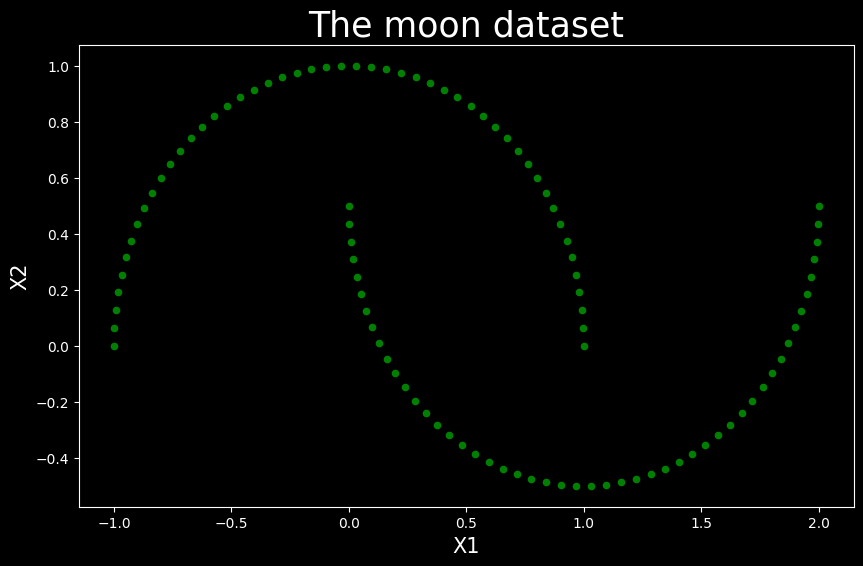

In [7]:
plt.figure(figsize = (10,6))
plt.scatter(Xm[:,0], Xm[:,1], s = 20, c = 'g')
plt.title('The moon dataset', fontsize = 25)
plt.xlabel('X1', fontsize = 15)
plt.ylabel('X2', fontsize = 15)
plt.show()

## Creating circles dataset

In [8]:
from sklearn.datasets import make_circles
data = make_circles(n_samples = 200, factor = 0.5, random_state = 42)

In [9]:
Xc = data[0]

## Visualize circles dataset

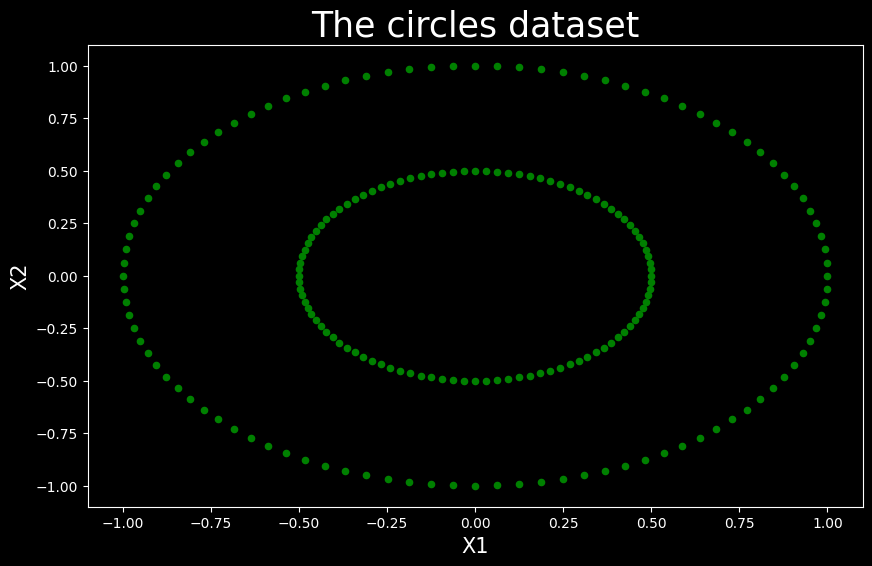

In [10]:
plt.figure(figsize = (10,6))
plt.scatter(Xc[:,0], Xc[:,1], s = 20, c = 'g')
plt.title('The circles dataset', fontsize = 25)
plt.xlabel('X1', fontsize = 15)
plt.ylabel('X2', fontsize = 15)
plt.show()

## Create Random Clusters Dataset

In [11]:
x1 = 1 + np.random.randn(200,1)
x2 = 10 + np.random.randn(200,1)
x3 = 3 + np.random.randn(200,1)
x4 = 5 + np.random.randn(200,1)
x5 = -3 + np.random.randn(200,1)
x6 = 2 + np.random.randn(200,1)

X1 = np.hstack((x1,x2))
X2 = np.hstack((x3,x4))
X3 = np.hstack((x5,x6))

Xr = np.vstack((X1,X2,X3))
Xr

array([[ 1.43158811, 10.72140854],
       [ 0.70887384,  9.81794223],
       [ 0.71424208,  8.60403898],
       ...,
       [-3.71934611,  1.82223386],
       [-3.59758422,  0.80542532],
       [-3.91115723,  2.40515214]])

## Visualize the dataset

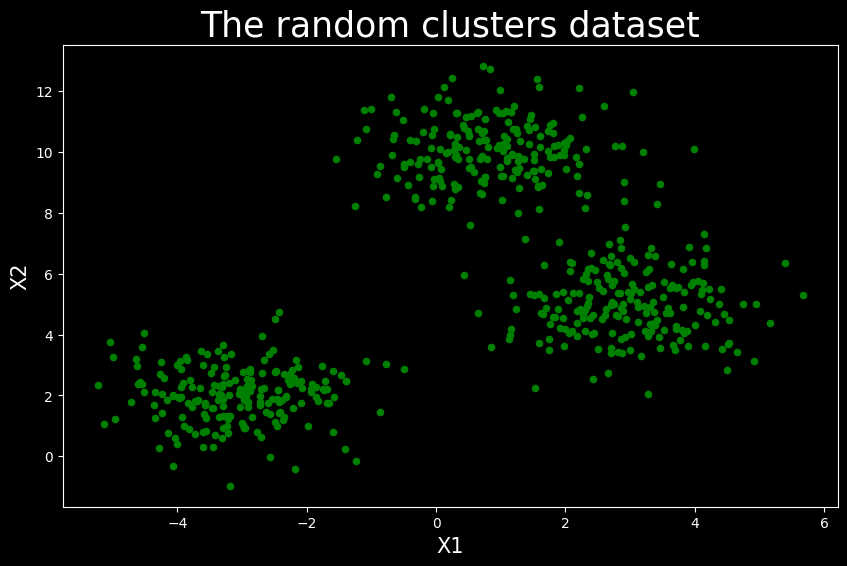

In [12]:
plt.figure(figsize = (10,6))
plt.scatter(Xr[:,0], Xr[:,1], s = 20, c = 'g')
plt.title('The random clusters dataset', fontsize = 25)
plt.xlabel('X1', fontsize = 15)
plt.ylabel('X2', fontsize = 15)
plt.show()

# Comparing DBSCAN and KMeans Clustering on moon dataset

In [13]:
from sklearn.cluster import DBSCAN, KMeans

In [14]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', n_init = 'auto')
y_kmeans = kmeans.fit_predict(Xm)

In [15]:
dbscan = DBSCAN(eps=0.2)
y_dbscan = dbscan.fit_predict(Xm)

## Visualizing Clustering

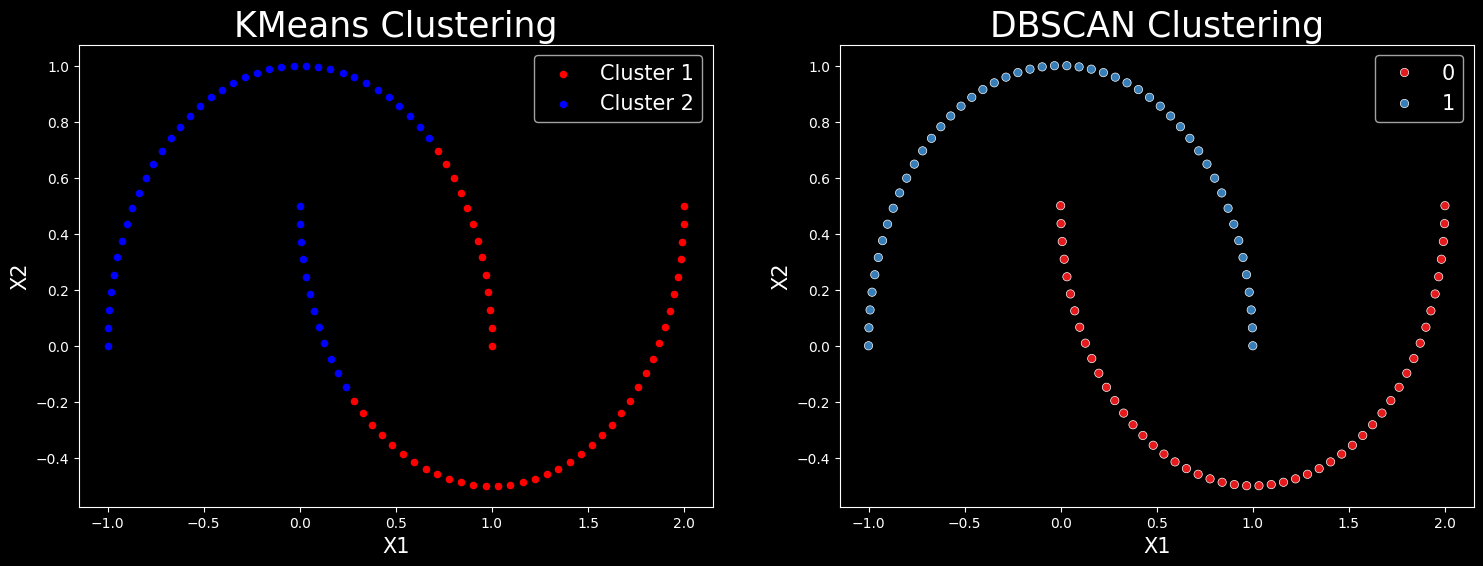

In [24]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

# Re-calculate KMeans for Xm
kmeans = KMeans(n_clusters = 2, init = 'k-means++', n_init = 'auto')
y_kmeans = kmeans.fit_predict(Xm)

# Re-calculate DBSCAN for Xm
dbscan = DBSCAN(eps=0.2)
y_dbscan = dbscan.fit_predict(Xm)

ax[0].scatter(Xm[y_kmeans == 0, 0], Xm[y_kmeans == 0, 1], s = 20, c = 'red', label = 'Cluster 1')
ax[0].scatter(Xm[y_kmeans == 1, 0], Xm[y_kmeans == 1, 1], s = 20, c = 'blue', label = 'Cluster 2')
ax[0].set_xlabel('X1', fontsize = 15)
ax[0].set_ylabel('X2', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('KMeans Clustering', fontsize = 25)

# Create a DataFrame for DBSCAN plotting
dbscan_df = pd.DataFrame(Xm, columns=['X1', 'X2'])
dbscan_df['cluster'] = y_dbscan

sns.scatterplot(data = dbscan_df, x = 'X1', y = 'X2', hue = 'cluster', palette = 'Set1', ax=ax[1])
ax[1].set_xlabel('X1', fontsize = 15)
ax[1].set_ylabel('X2', fontsize = 15)
ax[1].legend(fontsize = 15)
ax[1].set_title('DBSCAN Clustering', fontsize = 25)
plt.show()

# Comparing DBSCAN and KMeans Clustering on circles dataset

In [18]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', n_init ='auto')
dbscan = DBSCAN(eps = 0.2)
y_kmeans = kmeans.fit_predict(Xc)
y_dbscan = dbscan.fit_predict(Xc)

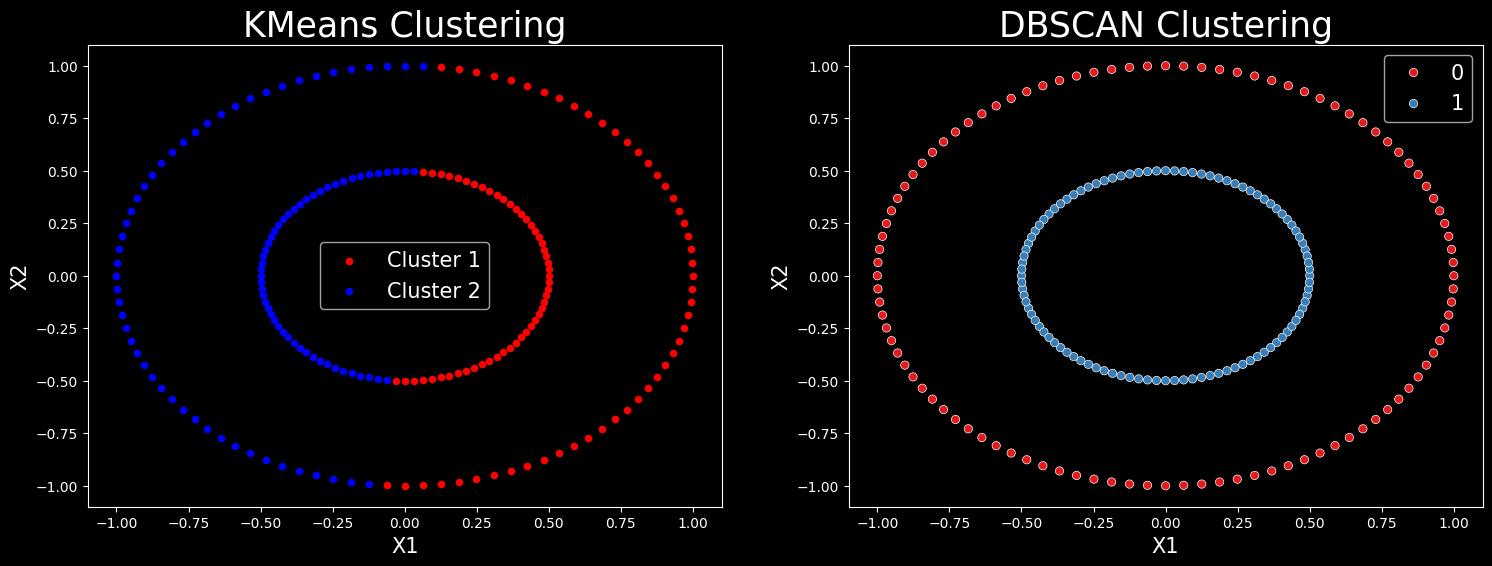

In [21]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

ax[0].scatter(Xc[y_kmeans == 0, 0], Xc[y_kmeans == 0, 1], s = 20, c = 'red', label = 'Cluster 1')
ax[0].scatter(Xc[y_kmeans == 1, 0], Xc[y_kmeans == 1, 1], s = 20, c = 'blue', label = 'Cluster 2')
ax[0].set_xlabel('X1', fontsize = 15)
ax[0].set_ylabel('X2', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('KMeans Clustering', fontsize = 25)

# Create a DataFrame for DBSCAN plotting
dbscan_df_circles = pd.DataFrame(Xc, columns=['X1', 'X2'])
dbscan_df_circles['cluster'] = y_dbscan

sns.scatterplot(data = dbscan_df_circles, x = 'X1', y = 'X2', hue = 'cluster', palette = 'Set1', ax=ax[1])
ax[1].set_xlabel('X1', fontsize = 15)
ax[1].set_ylabel('X2', fontsize = 15)
ax[1].legend(fontsize = 15)
ax[1].set_title('DBSCAN Clustering', fontsize = 25)
plt.show()

# Comparing DBSCAN and KMeans Clustering on Random Clusters dataset

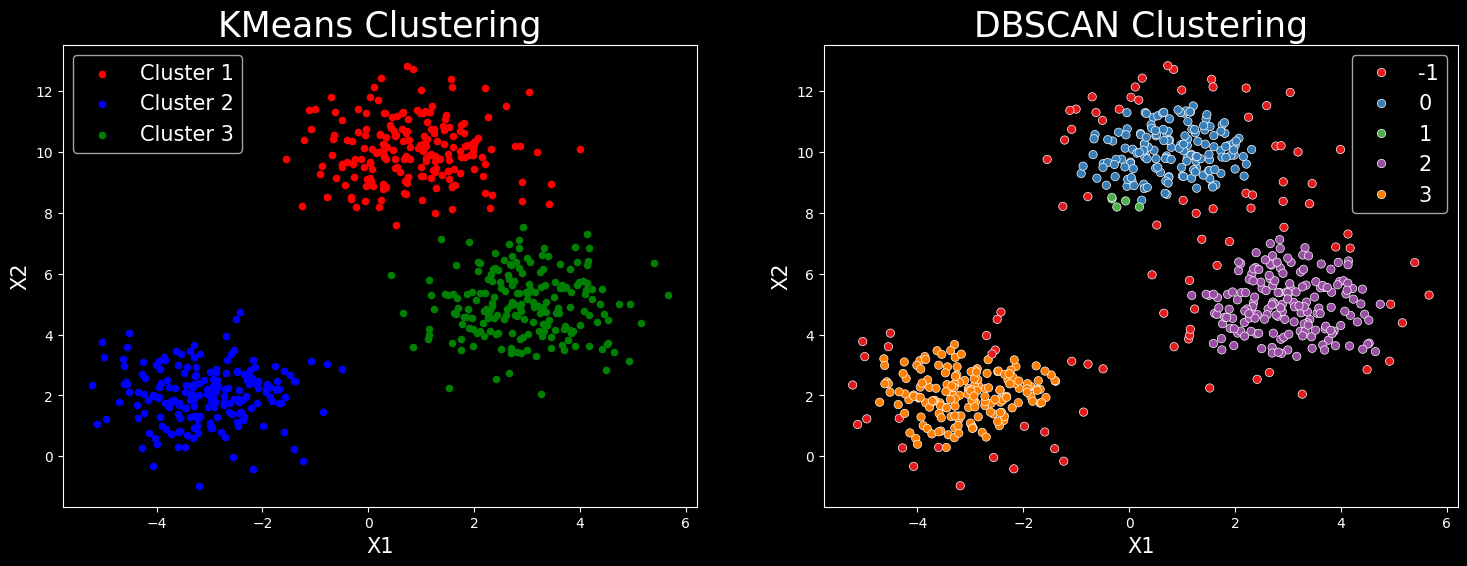

In [35]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

# Re-calculate KMeans for Xr
kmeans = KMeans(n_clusters = 3, init = 'k-means++', n_init = 'auto')
y_kmeans = kmeans.fit_predict(Xr)

# Re-calculate DBSCAN for Xr
dbscan = DBSCAN(eps=0.4)
y_dbscan = dbscan.fit_predict(Xr)

ax[0].scatter(Xr[y_kmeans == 0, 0], Xr[y_kmeans == 0, 1], s = 20, c = 'red', label = 'Cluster 1')
ax[0].scatter(Xr[y_kmeans == 1, 0], Xr[y_kmeans == 1, 1], s = 20, c = 'blue', label = 'Cluster 2')
ax[0].scatter(Xr[y_kmeans == 2, 0], Xr[y_kmeans == 2, 1], s = 20, c = 'green', label = 'Cluster 3')
ax[0].set_xlabel('X1', fontsize = 15)
ax[0].set_ylabel('X2', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('KMeans Clustering', fontsize = 25)

# Create a DataFrame for DBSCAN plotting
dbscan_df_random = pd.DataFrame(Xr, columns=['X1', 'X2'])
dbscan_df_random['cluster'] = y_dbscan

sns.scatterplot(data = dbscan_df_random, x = 'X1', y = 'X2', hue = 'cluster', palette = 'Set1', ax=ax[1])
ax[1].set_xlabel('X1', fontsize = 15)
ax[1].set_ylabel('X2', fontsize = 15)
ax[1].legend(fontsize = 15)
ax[1].set_title('DBSCAN Clustering', fontsize = 25)
plt.show()